### Çoklu Doğrusal Regresyon
Tekli doğrusal regresyon'dan farklı olarak, Çoklu Doğrusal Regresyon'da birden fazla bağımsız değişken (X) bulunur.

Bu modelin uygulamasında önceki derste olduğu gibi Seaborn kütüphanesinin mpg veri setini kullanacağız. Bu sefer bağımsız değişkenler beygir gücü (horsepower), weight (araç ağırlığı) ve displacement (motor hacmi) olacak. Modeli kurmadan önce çoklu bağlantı sorununu kontrol etmek adına yukarıdaki 3 değişken ve bağımlı değişkenimiz arasında korelasyon grafiği çizip sonucu yorumlayalım.

              horsepower    weight  displacement       mpg
horsepower      1.000000  0.864538      0.897257 -0.778427
weight          0.864538  1.000000      0.932994 -0.832244
displacement    0.897257  0.932994      1.000000 -0.805127
mpg            -0.778427 -0.832244     -0.805127  1.000000


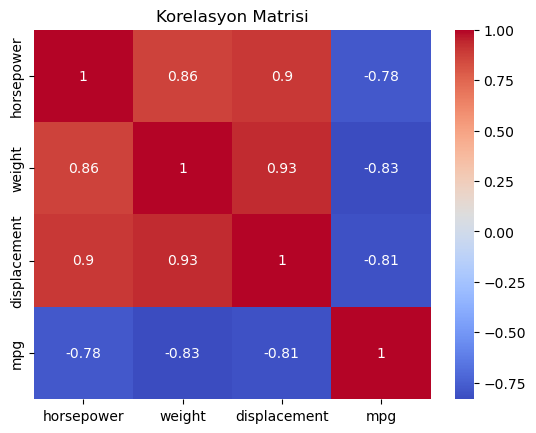

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = sns.load_dataset("mpg")
df = df.dropna(subset=['horsepower'])
# Burada hem her bir bağımsız değişken arasındaki ilişkiyi, hem de bu bağımsız değişkenlerin bağımlı değişken ile ilişkilerini görmeyi amaçlıyoruz.
korelasyon = df[['horsepower', 'weight', 'displacement', 'mpg']].corr()
print(korelasyon)
sns.heatmap(korelasyon, annot=True, cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.show()

In [2]:
# Önce Multicollinearity sorununu bilerek modelimizi eğitip sonuçları görelim. 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X_multi = df[['horsepower', 'weight', 'displacement']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print("Katsayılar:", model_multi.coef_)
print("Intercept:", model_multi.intercept_)

y_pred_multi = model_multi.predict(X_test)
r2_multi = r2_score(y_test, y_pred_multi)
print(f"R² (3 değişken): {r2_multi:.4f}")

Katsayılar: [-0.04328646 -0.00520866 -0.00881229]
Intercept: 45.403543281290396
R² (3 değişken): 0.6471


In [3]:
# Şimdi tek değişkenli mpg ile en yüksek düzeyde ilişkili araç ağırlığı değişkeni üzerinden model kuralım. 
X_single = df[['weight']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_single, y, test_size=0.2, random_state=42)

model_single = LinearRegression()
model_single.fit(X_train2, y_train2)

y_pred_single = model_single.predict(X_test2)
r2_single = r2_score(y_test2, y_pred_single)
print(f"R² (sadece weight): {r2_single:.4f}")

R² (sadece weight): 0.6533


### Multicollinearity Deneyi Sonucu
3 değişkenli model (horsepower+weight+displacement) R²=%64.71 verirken, sadece weight kullanan tek değişkenli model R²=%65.33 verdi yani ekstra 2 değişken hiçbir katkı sağlamadı, aksine çok hafif bir performans kaybına yol açtı. Bu, weight/horsepower/displacement arasındaki yüksek korelasyonun (multicollinearity), ekstra değişkenlerin modele yeni bilgi katmadığını, sadece gürültü eklediğini gösteriyor. Sonuç: Daha fazla değişken her zaman daha iyi model anlamına gelmez; birbirinden bağımsız bilgi taşıyan değişkenler seçmek önemlidir.